In [1]:
import pandas as pd


In [3]:
df = pd.read_csv("results.csv")
df

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False
...,...,...,...,...,...,...,...,...,...
49066,2026-01-18,Bolivia,Panama,1,1,Friendly,Tarija,Bolivia,False
49067,2026-01-18,Grenada,Jamaica,0,1,Friendly,St. George's,Grenada,False
49068,2026-01-22,Panama,Mexico,0,1,Friendly,Panama City,Panama,False
49069,2026-01-25,Bolivia,Mexico,0,1,Friendly,Santa Cruz,Bolivia,False


### Initial Data Loading

- The code first imports the pandas library, a powerful tool for data manipulation and analysis in Python.
- It then reads the `results.csv` file into a pandas DataFrame named `df`.
- `df.head()` is used to display the first few rows of the DataFrame, providing a quick overview of the data structure and content.

### 1. How many matches are in the dataset?

Using df.shape[0]; shape returns a tuple representing the dimensions of the DataFrame (rows, columns), and [0] accesses the number of rows.


In [4]:
print(f"Total number of matches: {df.shape[0]}")

Total number of matches: 49071


### 2. What is the earliest and latest year in the data?

The 'date' column was initially an object (string) type. To perform date-based operations, it's converted to datetime objects using pd.to_datetime(df['date']).
Once converted, df['date'].min().year extracts the earliest date and then its year.
Similarly, df['date'].max().year extracts the latest date and its year.


In [5]:
df['date'] = pd.to_datetime(df['date'])
earliest_year = df['date'].min().year
latest_year = df['date'].max().year
print(f"Earliest year: {earliest_year}")
print(f"Latest: {latest_year}")

Earliest year: 1872
Latest: 2026


### 3. How many unique countries are there?
Done by applying nunique() method to the country column.

In [6]:
unique_countries = df['country'].nunique()
print(f"Number of unique countries: {unique_countries}")

Number of unique countries: 269


### 4. Which team appears most frequently as home team?
The value_counts() method on the 'home_team' column returns a Series containing counts of unique values in descending order.
head(1) is then used to retrieve only the top entry, which represents the team that appears most frequently as the home team.

In [7]:
most_frequent_home_team = df['home_team'].value_counts().head(1)
print(f"Most frequent home team:\n{most_frequent_home_team}")

Most frequent home team:
home_team
Brazil    610
Name: count, dtype: int64


## Goals Analysis
A new column named 'total_goals' is created by summing the 'home_score' and 'away_score' for each match. This provides a single metric for the total number of goals in a game.


In [9]:
df["total_goals"] = df["home_score"] + df["away_score"]
display(df.head())

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,total_goals
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,0
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,6
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,3
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,4
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,3


### 5. What is the average number of goals per match?

Mean of total goals column

In [10]:
average_goals_per_match = df['total_goals'].mean()
print(f"The average number of goals per match is: {average_goals_per_match:.2f}")

The average number of goals per match is: 2.94


### 6. What is the highest scoring match?

- First, `df['total_goals'].max()` finds the maximum value in the 'total_goals' column.
- Then, the DataFrame is filtered (`df[df['total_goals'] == highest_goals]`) to retrieve all rows where the 'total_goals' matches this maximum value. This handles cases where multiple matches might share the highest score.

In [11]:
highest_goals = df['total_goals'].max()
highest_scoring_matches = df[df['total_goals'] == highest_goals]

print(f"The highest number of goals scored in a single match is: {highest_goals}")
print("Details of the highest scoring match(es):")
display(highest_scoring_matches[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'total_goals', 'tournament', 'city', 'country']])

The highest number of goals scored in a single match is: 31
Details of the highest scoring match(es):


,date,home_team,away_team,home_score,away_score,total_goals,tournament,city,country
25420,2001-04-11,Australia,American Samoa,31,0,31,FIFA World Cup qualification,Coffs Harbour,Australia


### 7. Are more goals scored at home or away?

- The total goals scored by home teams are calculated by summing the 'home_score' column (`df['home_score'].sum()`).
- Similarly, the total goals scored by away teams are calculated from the 'away_score' column (`df['away_score'].sum()`).
- An if-elif-else statement then compares these two totals to determine and print which scenario (home, away, or equal) resulted in more goals.

In [12]:
total_home_goals = df['home_score'].sum()
total_away_goals = df['away_score'].sum()

print(f"Total goals scored by home teams: {total_home_goals}")
print(f"Total goals scored by away teams: {total_away_goals}")

if total_home_goals > total_away_goals:
    print("More goals are scored at home.")
elif total_away_goals > total_home_goals:
    print("More goals are scored away.")
else:
    print("An equal number of goals are scored at home and away.")

Total goals scored by home teams: 86182
Total goals scored by away teams: 58011
More goals are scored at home.


### 8. What is the most common total goals value?

- Similar to finding the most frequent home team, `value_counts()` on the 'total_goals' column counts the occurrences of each total goal value.
- `head(1)` then returns the total goal value that appeared most frequently.

In [13]:
most_common_total_goals = df['total_goals'].value_counts().head(1)
most_common_total_goals

,count
total_goals,
2,10896


## 9 Calculate Home Win Percentage

- A helper function `get_match_result` is defined. This function takes a row of the DataFrame as input.
- It compares 'home_score' and 'away_score' to return 'Home Win', 'Away Win', or 'Draw'.
- This function is applied to each row of the DataFrame using `df.apply(get_match_result, axis=1)` to create a new 'result' column, categorizing the outcome of each match.

In [15]:
def get_match_result(row):
    if row['home_score'] > row['away_score']:
        return 'Home Win'
    elif row['away_score'] > row['home_score']:
        return 'Away Win'
    else:
        return 'Draw'

df['result'] = df.apply(get_match_result, axis=1)
display(df.head())

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,total_goals,result
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,0,Draw
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,6,Home Win
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,3,Home Win
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,4,Draw
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,3,Home Win


**10. Home Win Advantage**

- To calculate the home win percentage, the DataFrame is filtered to include only rows where the 'result' is 'Home Win' (`df[df['result'] == 'Home Win']`).
- The number of such rows is divided by the total number of matches (`df.shape[0]`) and multiplied by 100 to get the percentage.

In [18]:
away_win_percentage = (df[df['result'] == 'Away Win'].shape[0] / df.shape[0]) * 100
draw_percentage = (df[df['result'] == 'Draw'].shape[0] / df.shape[0]) * 100

print(f"Percentage of matches that resulted in a Home Win: {home_win_percentage:.2f}%")
print(f"Percentage of matches that resulted in an Away Win: {away_win_percentage:.2f}%")
print(f"Percentage of matches that resulted in a Draw: {draw_percentage:.2f}%")

Percentage of matches that resulted in a Home Win: 49.00%
Percentage of matches that resulted in an Away Win: 28.27%
Percentage of matches that resulted in a Draw: 22.73%


##11. Determine Most Winning Country

- A function `get_winning_team` is created to extract the name of the winning team for each match.
- If the result is 'Home Win', it returns the 'home_team'; if 'Away Win', it returns the 'away_team'. For a 'Draw', it returns `None`.
- This function is applied across each row to populate a new 'winning_team' column.



In [24]:
def get_winning_team(row):
    if row['result'] == 'Home Win':
        return row['home_team']
    elif row['result'] == 'Away Win':
        return row['away_team']
    else:
        return None

df['winning_team'] = df.apply(get_winning_team, axis=1)
df['winning_team'].head()


,winning_team
0,None
1,England
2,Scotland
3,None
4,Scotland


- `df['winning_team'].value_counts()` counts how many times each team appears as a winner.
- `idxmax()` then finds the index (team name) of the maximum value (highest win count) in the resulting Series.
- `max()` retrieves the actual highest win count.

In [26]:
team_wins = df['winning_team'].value_counts()
most_winning_team = team_wins.idxmax()
max_wins = team_wins.max()

print(f"The team with the most wins is '{most_winning_team}' with {max_wins} wins.")

The team with the most wins is 'Brazil' with 669 wins.


**11. Histogram of goals**

- The `matplotlib.pyplot` library (aliased as `plt`) is imported for plotting.
- `df["total_goals"].hist(bins=15)` generates a histogram of the 'total_goals' column, dividing the data into 15 bins to show the frequency distribution of total goals scored per match.
- Titles and axis labels are added for clarity, and `plt.show()` displays the plot.

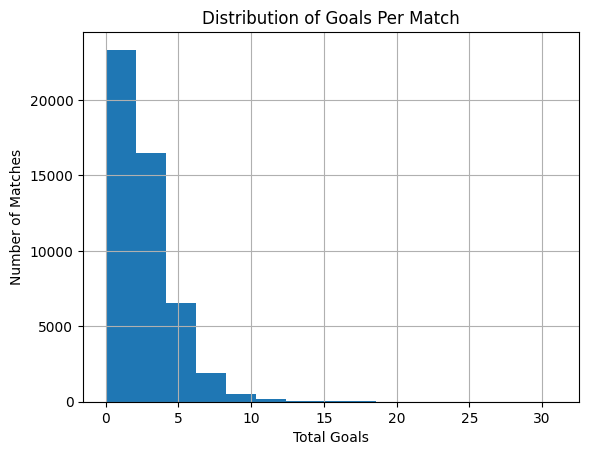

In [20]:
import matplotlib.pyplot as plt

df["total_goals"].hist(bins=15)
plt.title("Distribution of Goals Per Match")
plt.xlabel("Total Goals")
plt.ylabel("Number of Matches")
plt.show()

- This code uses `matplotlib.pyplot` to create a bar chart.
- `match_outcomes` and `percentages` lists store the labels and calculated percentages (Home Win, Away Win, Draw).
- `plt.bar()` creates the bar chart with specified colors.
- Titles, labels, and y-axis limits are set, and a loop adds text labels (percentages) on top of each bar for easy reading. `plt.show()` displays the plot.

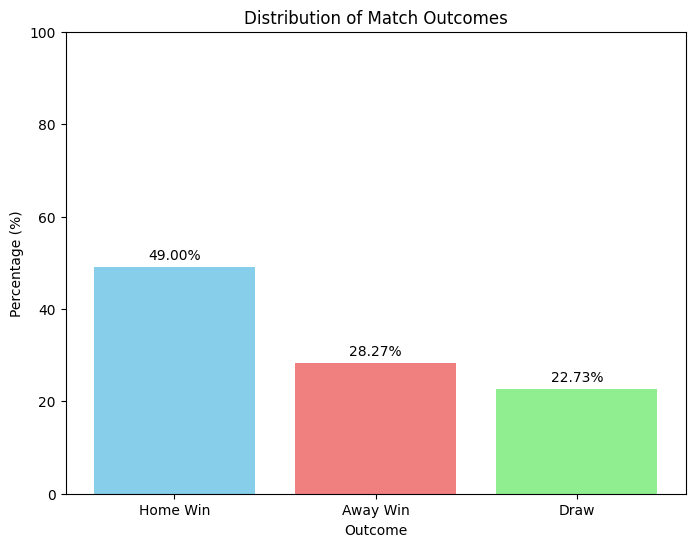

In [21]:
import matplotlib.pyplot as plt

match_outcomes = ['Home Win', 'Away Win', 'Draw']
percentages = [home_win_percentage, away_win_percentage, draw_percentage]

plt.figure(figsize=(8, 6))
plt.bar(match_outcomes, percentages, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Distribution of Match Outcomes')
plt.xlabel('Outcome')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100) # Ensure y-axis goes up to 100%
for i, percentage in enumerate(percentages):
    plt.text(i, percentage + 1, f'{percentage:.2f}%', ha='center', va='bottom')
plt.show()

## Find Top 10 Teams by Wins


In [27]:
team_wins.head(10)


,count
winning_team,
Brazil,669
England,623
Germany,595
Argentina,586
Sweden,539
South Korea,536
Mexico,510
France,474
Italy,474
